### DEG Filtering

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os

print("Libraries loaded")

Libraries loaded


In [3]:
data_processed = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/processed")

datasets = {
    "Vitiligo": pd.read_csv(f"{data_processed}/GSE65127_vitiligo_expr.csv", index_col=0),
    "SLE": pd.read_csv(f"{data_processed}/GSE318067_SLE_expr.csv", index_col=0),
    "RA": pd.read_csv(f"{data_processed}/GSE93272_RA_expr.csv", index_col=0),
    "T1D": pd.read_csv(f"{data_processed}/GSE55098_T1D_expr.csv", index_col=0)
}

for disease, df in datasets.items():
    print(f"{disease}: {df.shape}")

Vitiligo: (21655, 40)
SLE: (21655, 82)
RA: (21655, 275)
T1D: (21655, 22)


In [ ]:
## Extract sample metadata to identify case/control labels
## GEO files already downloaded — loading from disk (no re-download)

import GEOparse

data_raw = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/raw")

# Load GSE65127 to extract sample metadata
gse65127 = GEOparse.get_GEO(geo="GSE65127", destdir=data_raw, silent=True)

# Look at one sample's metadata
sample_id = list(gse65127.gsms.keys())[0]
print(sample_id)
print(gse65127.gsms[sample_id].metadata.keys())

/Users/mohammadabuhuzaifa/Pan-Autoimmune-miRNA-ML/mirna_env/lib/python3.11/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


GSM1587709
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count'])


In [6]:
## Inspect title metadata to extract case/control labels
# Print all sample titles to understand case/control labeling
for gsm_id, gsm in gse65127.gsms.items():
    print(gsm_id, gsm.metadata['title'][0])

GSM1587709 Healthy Volunteer [9001_S07_NST]
GSM1587710 Healthy Volunteer [9002_S01_NST]
GSM1587711 Healthy Volunteer [9003_S02_NST]
GSM1587712 Healthy Volunteer [9004_S03_NST]
GSM1587713 Healthy Volunteer [9005_S04_NST]
GSM1587714 Healthy Volunteer [9006_S05_NST]
GSM1587715 Healthy Volunteer [9007_S08_NST]
GSM1587716 Healthy Volunteer [9008_S09_NST]
GSM1587717 Healthy Volunteer [9009_S10_NST]
GSM1587718 Healthy Volunteer [9010_S06_NST]
GSM1587719 Lesional [9021_S11_LST]
GSM1587720 Lesional [9022_S12_LST]
GSM1587721 Lesional [9023_S13_LST]
GSM1587722 Lesional [9024_S14_LST]
GSM1587723 Lesional [9025_S15_LST]
GSM1587724 Lesional [9026_S16_LST]
GSM1587725 Lesional [9027_S17_LST]
GSM1587726 Lesional [9028_S18_LST]
GSM1587727 Lesional [9029_S19_LST]
GSM1587728 Lesional [9030_S20_LST]
GSM1587729 Non Lesional [9021_S11_NLST]
GSM1587730 Non Lesional [9022_S12_NLST]
GSM1587731 Non Lesional [9023_S13_NLST]
GSM1587732 Non Lesional [9024_S14_NLST]
GSM1587733 Non Lesional [9025_S15_NLST]
GSM1587734

In [10]:
## Assign case/control labels for Vitiligo (GSE65127)
vitiligo_labels = {}
for gsm_id, gsm in gse65127.gsms.items():
    title = gsm.metadata['title'][0]
    if 'Healthy Volunteer' in title:
        vitiligo_labels[gsm_id] = 'control'
    elif 'Lesional' in title:  # catches Lesional, Non Lesional, Peri-Lesional
        vitiligo_labels[gsm_id] = 'case'

print(f"Cases: {sum(v=='case' for v in vitiligo_labels.values())}")
print(f"Controls: {sum(v=='control' for v in vitiligo_labels.values())}")

Cases: 30
Controls: 10


In [8]:
## Load remaining GEO objects and inspect sample titles
gse_objects = {
    "SLE": GEOparse.get_GEO(geo="GSE318067", destdir=data_raw, silent=True),
    "RA": GEOparse.get_GEO(geo="GSE93272", destdir=data_raw, silent=True),
    "T1D": GEOparse.get_GEO(geo="GSE55098", destdir=data_raw, silent=True)
}

for disease, gse in gse_objects.items():
    print(f"\n--- {disease} ---")
    for gsm_id, gsm in list(gse.gsms.items())[:5]:
        print(gsm_id, gsm.metadata['title'][0])

/Users/mohammadabuhuzaifa/Pan-Autoimmune-miRNA-ML/mirna_env/lib/python3.11/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
/Users/mohammadabuhuzaifa/Pan-Autoimmune-miRNA-ML/mirna_env/lib/python3.11/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
/Users/mohammadabuhuzaifa/Pan-Autoimmune-miRNA-ML/mirna_env/lib/python3.11/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")



--- SLE ---
GSM9485638 SLE_Control HD A0221011
GSM9485639 SLE_Control HD A0221018
GSM9485640 SLE_Control HD A0221024
GSM9485641 SLE_Control HD A0221030
GSM9485642 SLE_Control HD A0221031

--- RA ---
GSM2449608 Whole blood from healthy control(HC003_1)
GSM2449609 Whole blood from healthy control(HC004_1)
GSM2449610 Whole blood from healthy control(HC005_1)
GSM2449611 Whole blood from healthy control(HC006_1)
GSM2449612 Whole blood from healthy control(HC007_1)

--- T1D ---
GSM1329616 Normal control  1 (mRNA)
GSM1329617 Normal control  2 (mRNA)
GSM1329618 Normal control  3 (mRNA)
GSM1329619 Normal control  4 (mRNA)
GSM1329620 Normal control  5 (mRNA)


In [ ]:
## Get unique title patterns for each disease

for disease, gse in gse_objects.items():
    print(f"\n--- {disease} unique patterns ---")
    titles = set()
    for gsm_id, gsm in gse.gsms.items():
        title = gsm.metadata['title'][0]
        print(title)


--- SLE unique patterns ---
SLE_Control HD A0221011
SLE_Control HD A0221018
SLE_Control HD A0221024
SLE_Control HD A0221030
SLE_Control HD A0221031
SLE_Control HD A0221032
SLE_Control HD A0221035
SLE_Control HD A0221036
SLE_Control HD A0221039
SLE_Control HD A0221040
SLE_Control HD A0221044
SLE_Control HD A0221045
SLE_Control HD A0221051
SLE_Control HD A0221052
SLE_Control HD A0221055
SLE_Control HD A0221064
SLE_Control HD A0221065
SLE_Control HD A0221068
SLE_Control HD A0221100
SLE_Control HD A0221107
SLE_Control HD A0221108
SLE_Control HD A0221113
SLE_Control HD A0221114
SLE_Control HD A0221118
SLE_Control HD A0221123
SLE_Control HD A0221124
SLE_Control HD A0221136
SLE_Control HD A0221137
SLE_Control HD A0221153
SLE_Control HD A0221161
SLE_Control HD A0221162
SLE_Control HD A0221163
SLE_Control HD A0221168
SLE_Control HD A0221169
SLE_Control HD A0221178
SLE_Control HD A0221180
SLE_Control HD A0221182
SLE_Control HD A0221187
SLE_Control HD A0221189
SLE_Control HD A0221192
SLE_Control

In [15]:
## Assign case/control labels for SLE, RA, and T1D based on title inspection above

# SLE (GSE318067)
sle_labels = {}
for gsm_id, gsm in gse_objects["SLE"].gsms.items():
    title = gsm.metadata['title'][0]
    if 'SLE_Control' in title:
        sle_labels[gsm_id] = 'control'
    elif title.startswith('SLE'):
        sle_labels[gsm_id] = 'case'

# RA (GSE93272)
ra_labels = {}
for gsm_id, gsm in gse_objects["RA"].gsms.items():
    title = gsm.metadata['title'][0]
    if 'healthy control' in title:
        ra_labels[gsm_id] = 'control'
    elif 'rheumatoid arthritis' in title:
        ra_labels[gsm_id] = 'case'

# T1D (GSE55098)
t1d_labels = {}
for gsm_id, gsm in gse_objects["T1D"].gsms.items():
    title = gsm.metadata['title'][0]
    if 'Normal control' in title:
        t1d_labels[gsm_id] = 'control'
    elif 'Newly-diagnosed' in title:
        t1d_labels[gsm_id] = 'case'

# Summary
for disease, labels in [("SLE", sle_labels), ("RA", ra_labels), ("T1D", t1d_labels)]:
    cases = sum(v=='case' for v in labels.values())
    controls = sum(v=='control' for v in labels.values())
    print(f"{disease} — Cases: {cases}, Controls: {controls}")

SLE — Cases: 41, Controls: 41
RA — Cases: 232, Controls: 43
T1D — Cases: 12, Controls: 10


In [19]:
## Check distribution of p-values and fold changes before filtering
for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    full = deg_results[disease]["full"]
    sig_raw = full[full['pvalue'] < 0.05]
    sig_fc = full[full['log2FC'].abs() > 1]
    sig_adj = full[full['adj_pvalue'] < 0.05]
    print(f"{disease}: raw p<0.05: {len(sig_raw)}, |log2FC|>1: {len(sig_fc)}, adj_p<0.05: {len(sig_adj)}")

Vitiligo: raw p<0.05: 6563, |log2FC|>1: 0, adj_p<0.05: 2745
SLE: raw p<0.05: 6408, |log2FC|>1: 0, adj_p<0.05: 3265
RA: raw p<0.05: 10663, |log2FC|>1: 0, adj_p<0.05: 9127
T1D: raw p<0.05: 2353, |log2FC|>1: 0, adj_p<0.05: 0


In [25]:
## DEG analysis using independent t-test + Benjamini-Hochberg correction

def run_deg_analysis(expr_df, labels, disease_name, data_processed):
    
    # Separate case and control samples
    case_samples = [s for s, l in labels.items() if l == 'case' and s in expr_df.columns]
    control_samples = [s for s, l in labels.items() if l == 'control' and s in expr_df.columns]
    
    case_data = expr_df[case_samples]
    control_data = expr_df[control_samples]
    
    # Run t-test for each gene
    results = []
    for gene in expr_df.index:
        case_vals = case_data.loc[gene].values
        ctrl_vals = control_data.loc[gene].values
        t_stat, p_val = stats.ttest_ind(case_vals, ctrl_vals)
        log2fc = case_vals.mean() - ctrl_vals.mean()
        results.append({'gene': gene, 'log2FC': log2fc, 'pvalue': p_val})
    
    results_df = pd.DataFrame(results).set_index('gene')
    
    # BH correction
    _, adj_pvals, _, _ = multipletests(results_df['pvalue'].fillna(1), method='fdr_bh')
    results_df['adj_pvalue'] = adj_pvals
    
    # Filter significant DEGs
    sig_degs = results_df[
        (results_df['adj_pvalue'] < 0.05)
    ]
    
    # Save
    filename = f"{disease_name}_DEGs.csv"
    sig_degs.to_csv(f"{data_processed}/{filename}")
    print(f"{disease_name}: {len(sig_degs)} DEGs — Up: {(sig_degs['log2FC']>0).sum()}, Down: {(sig_degs['log2FC']<0).sum()}")
    
    return results_df, sig_degs

In [26]:
## Run DEG analysis for all four diseases
deg_results = {}

for disease, expr_df, labels in [
    ("Vitiligo", datasets["Vitiligo"], vitiligo_labels),
    ("SLE", datasets["SLE"], sle_labels),
    ("RA", datasets["RA"], ra_labels),
    ("T1D", datasets["T1D"], t1d_labels)
]:
    full_results, sig_degs = run_deg_analysis(expr_df, labels, disease, data_processed)
    deg_results[disease] = {"full": full_results, "sig": sig_degs}

Vitiligo: 2745 DEGs — Up: 1251, Down: 1494
SLE: 3265 DEGs — Up: 1405, Down: 1860
RA: 9127 DEGs — Up: 4128, Down: 4999
T1D: 0 DEGs — Up: 0, Down: 0


In [28]:
## Check for anchor genes PTPN22 and NLRP1 in DEG results
anchor_genes = ['PTPN22', 'NLRP1']

for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    sig = deg_results[disease]["sig"]
    found = [g for g in anchor_genes if g in sig.index]
    print(f"{disease}: {found if found else 'Not in significant DEGs'}")

Vitiligo: Not in significant DEGs
SLE: Not in significant DEGs
RA: ['PTPN22', 'NLRP1']
T1D: Not in significant DEGs


In [30]:
## Check PTPN22 and NLRP1 expression trends across all diseases
for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    full = deg_results[disease]["full"]
    for gene in anchor_genes:
        if gene in full.index:
            row = full.loc[gene]
            print(f"{disease} - {gene}: log2FC={row['log2FC']:.3f}, adj_p={row['adj_pvalue']:.3f}")

Vitiligo - PTPN22: log2FC=0.050, adj_p=0.673
Vitiligo - NLRP1: log2FC=0.129, adj_p=0.307
SLE - PTPN22: log2FC=0.062, adj_p=0.627
SLE - NLRP1: log2FC=-0.008, adj_p=0.949
RA - PTPN22: log2FC=0.338, adj_p=0.000
RA - NLRP1: log2FC=-0.237, adj_p=0.000
T1D - PTPN22: log2FC=-0.047, adj_p=0.883
T1D - NLRP1: log2FC=0.256, adj_p=0.113


In [31]:
## Save full DEG results for all diseases
for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    full = deg_results[disease]["full"]
    full.to_csv(f"{data_processed}/{disease}_full_DEG_results.csv")
    print(f"Saved: {disease}_full_DEG_results.csv")

Saved: Vitiligo_full_DEG_results.csv
Saved: SLE_full_DEG_results.csv
Saved: RA_full_DEG_results.csv
Saved: T1D_full_DEG_results.csv


In [32]:
## Save filtered DEG gene lists for network construction
for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    deg_results[disease]["sig"].to_csv(f"{data_processed}/{disease}_DEGs.csv")
    print(f"Saved: {disease}_DEGs.csv — {len(deg_results[disease]['sig'])} genes")

Saved: Vitiligo_DEGs.csv — 2745 genes
Saved: SLE_DEGs.csv — 3265 genes
Saved: RA_DEGs.csv — 9127 genes
Saved: T1D_DEGs.csv — 0 genes


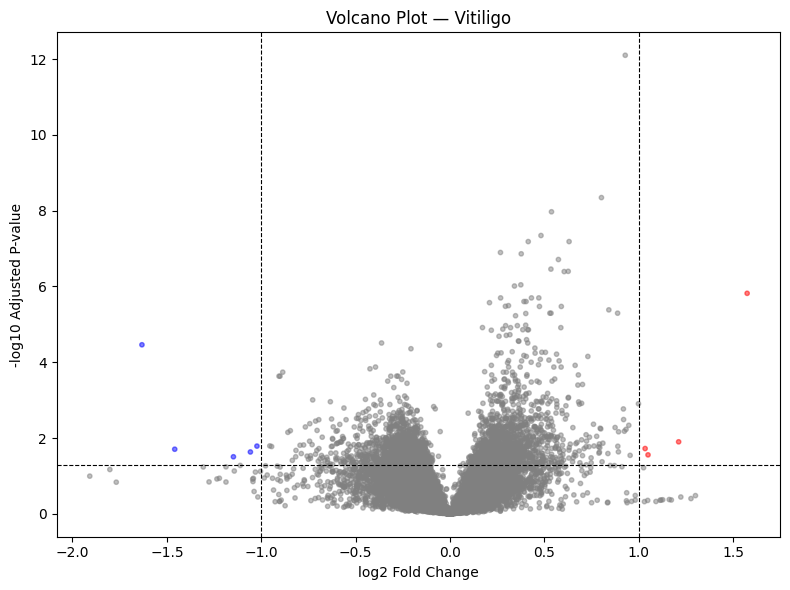

Saved: Vitiligo_volcano.png


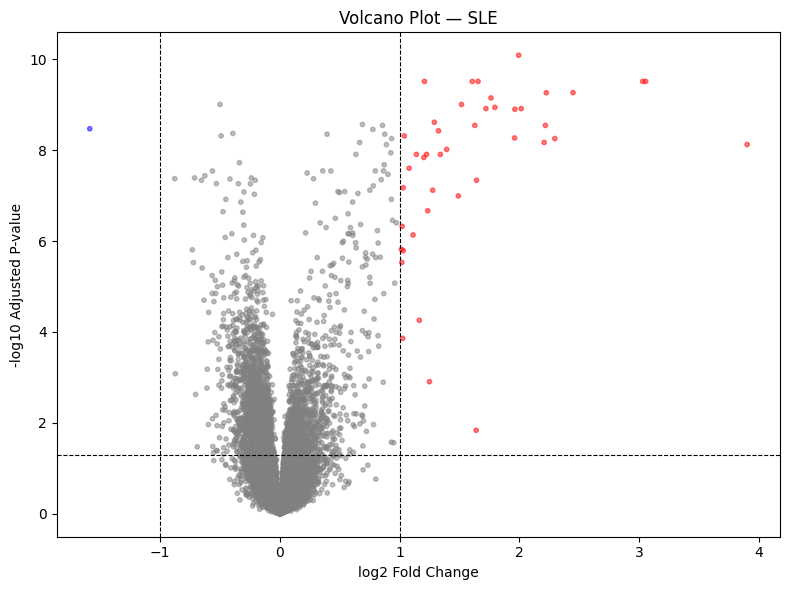

Saved: SLE_volcano.png


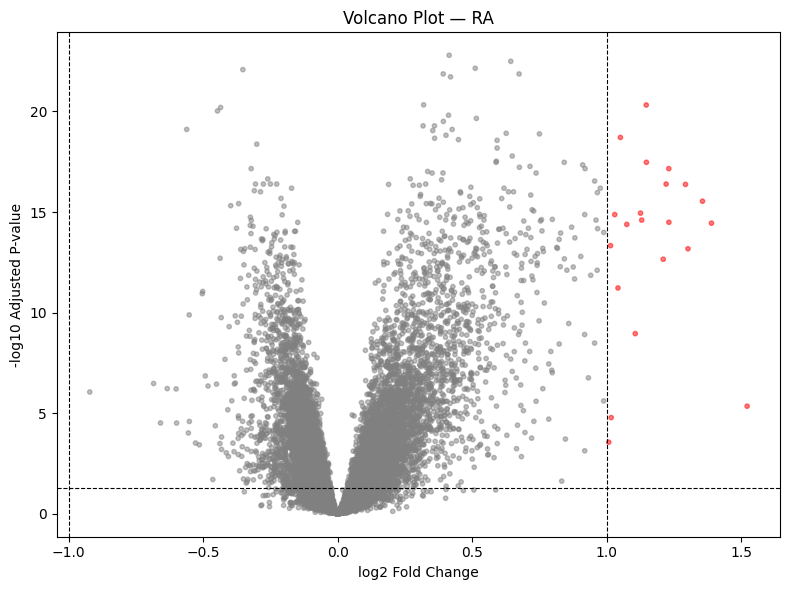

Saved: RA_volcano.png


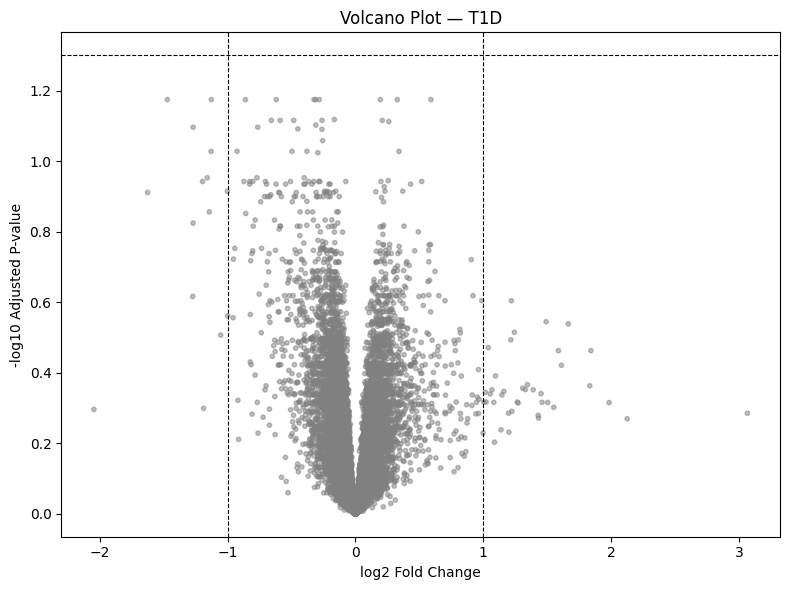

Saved: T1D_volcano.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_volcano(disease, results_df, save_path):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    log2fc = results_df['log2FC']
    pval = -np.log10(results_df['adj_pvalue'].replace(0, 1e-300))
    
    colors = ['grey'] * len(results_df)
    for i, (fc, p) in enumerate(zip(log2fc, results_df['adj_pvalue'])):
        if p < 0.05 and fc > 1: colors[i] = 'red'
        elif p < 0.05 and fc < -1: colors[i] = 'blue'
    
    ax.scatter(log2fc, pval, c=colors, alpha=0.5, s=10)
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-1, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('log2 Fold Change')
    ax.set_ylabel('-log10 Adjusted P-value')
    ax.set_title(f'Volcano Plot — {disease}')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/{disease}_volcano.png", dpi=300)
    plt.show()
    print(f"Saved: {disease}_volcano.png")

figures_path = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/results/figures")
os.makedirs(figures_path, exist_ok=True)

for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    full = deg_results[disease]["full"]
    plot_volcano(disease, full, figures_path)